## 📊 Plotting

**Concepts:** [Graph model and plot views](../problem.md#the-graph-model) **Advanced API:** [📊 Plotting](lo14_plotting.ipynb)

This notebook explains the main plotting functions available for a [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) object.

These plotting methods are natively optimized to return high-performance, lightweight, and modern vector **SVG representations**([svgplot](../autoapi/optiwindnet/svg/index.rst#optiwindnet.svg.svgplot)/[svgpplot](../autoapi/optiwindnet/svg/index.rst#optiwindnet.svg.svgpplot)) by default inside notebooks. However, they also seamlessly switch to **Matplotlib backends**([gplot](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.gplot)/[pplot](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.pplot)) when you supply a custom target axes (e.g. `ax=...`), giving you the best of both worlds: clean direct display and advanced layout customizability.

### Import required modules

In [1]:
from optiwindnet.api import WindFarmNetwork, load_repository

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

### Create a sample network

> Note: [load_repository()](../autoapi/optiwindnet/importer/index.rst#optiwindnet.importer.load_repository) loads multiple locations from a given path. If no path is given, it loads the built-in locations (more details in [🗂️ Locations](hi12_locations.ipynb)).

In [3]:
locations = load_repository()
wfn = WindFarmNetwork(L=locations.anholt, cables=[(2, 1500.0), (5, 1800.0)])

### Plot location geometry (`L`):

`L` contains only the **raw location data**, such as turbine and substation coordinates, borders, and obstacles, **without any links or connections** between nodes.

As a result, [wfn.plot_location()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_location) will appear as an **edgeless graph**, showing only the borders and node elements without network links/edges. Turbines are plotted as _circles_, and substations as _squares_.

This plot is useful to check if the location data was correctly loaded into the [WindFarmNetwork()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance, before running the optimization.

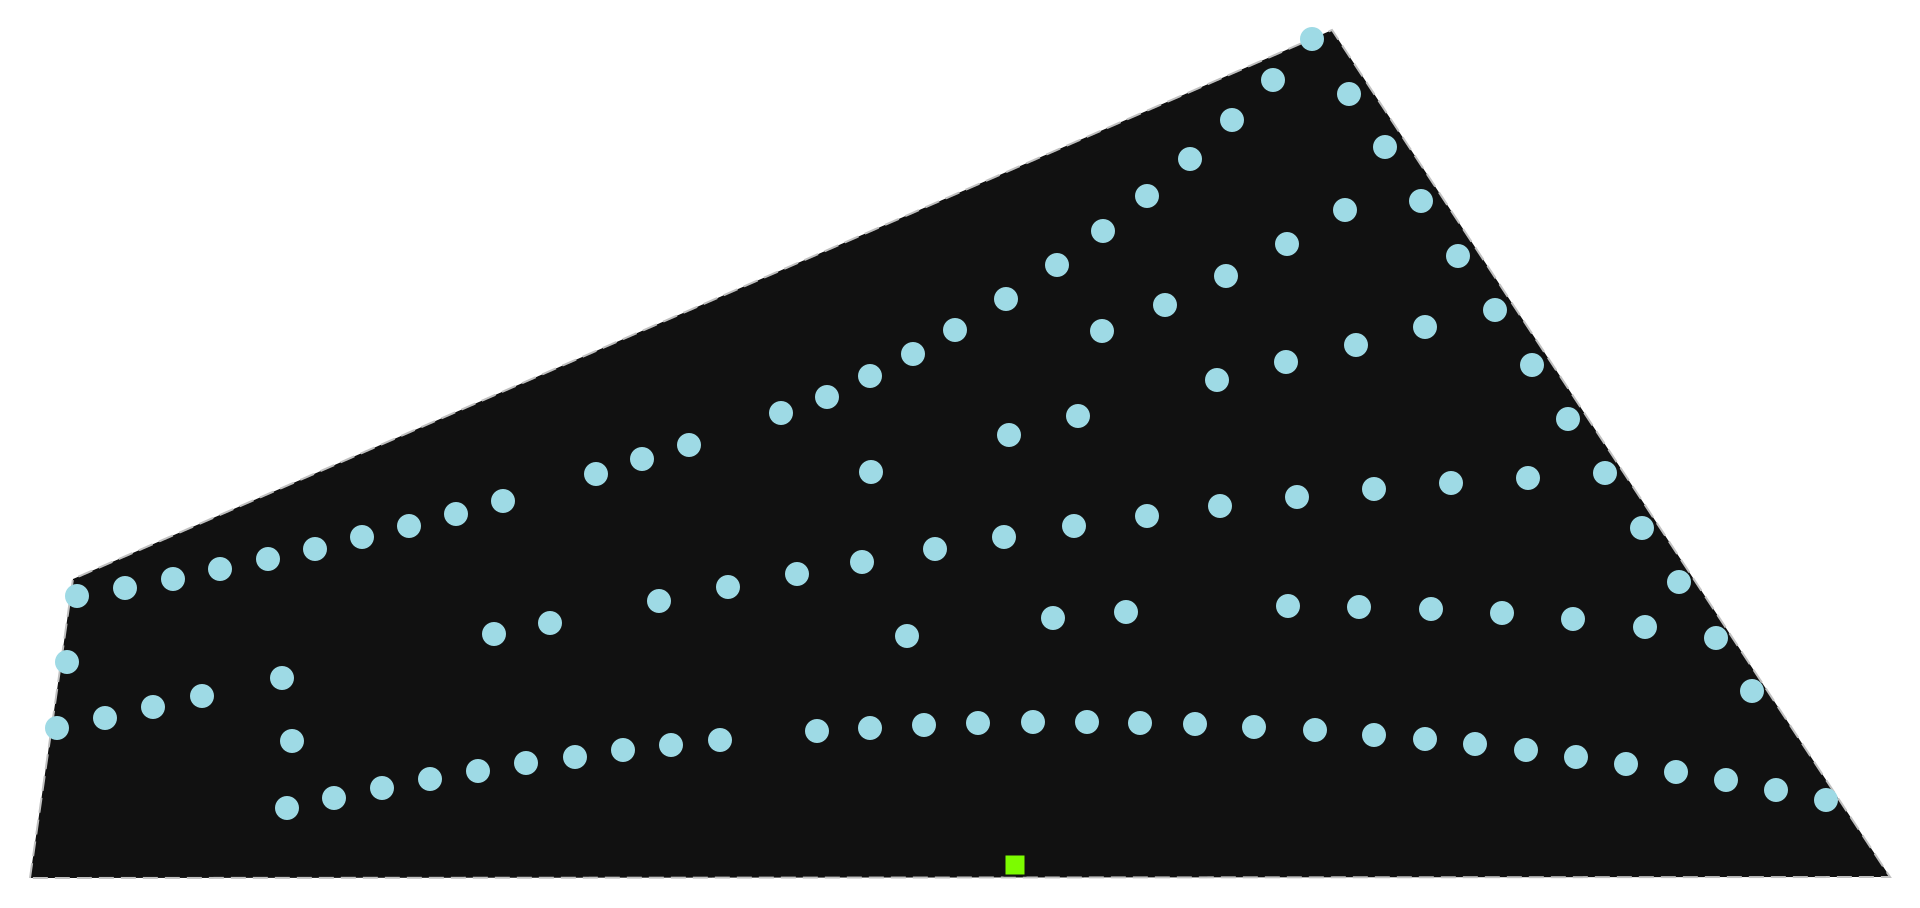

In [4]:
wfn.plot_location()

> **Tip**: In a notebook, just put `wfn` as the last line of a cell for plotting G.
>
> - Before optimization (no `G` yet), it renders the location geometry `L`.
> - If `G` exists (e.g. after a call to [optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize)), it automatically renders `G`.

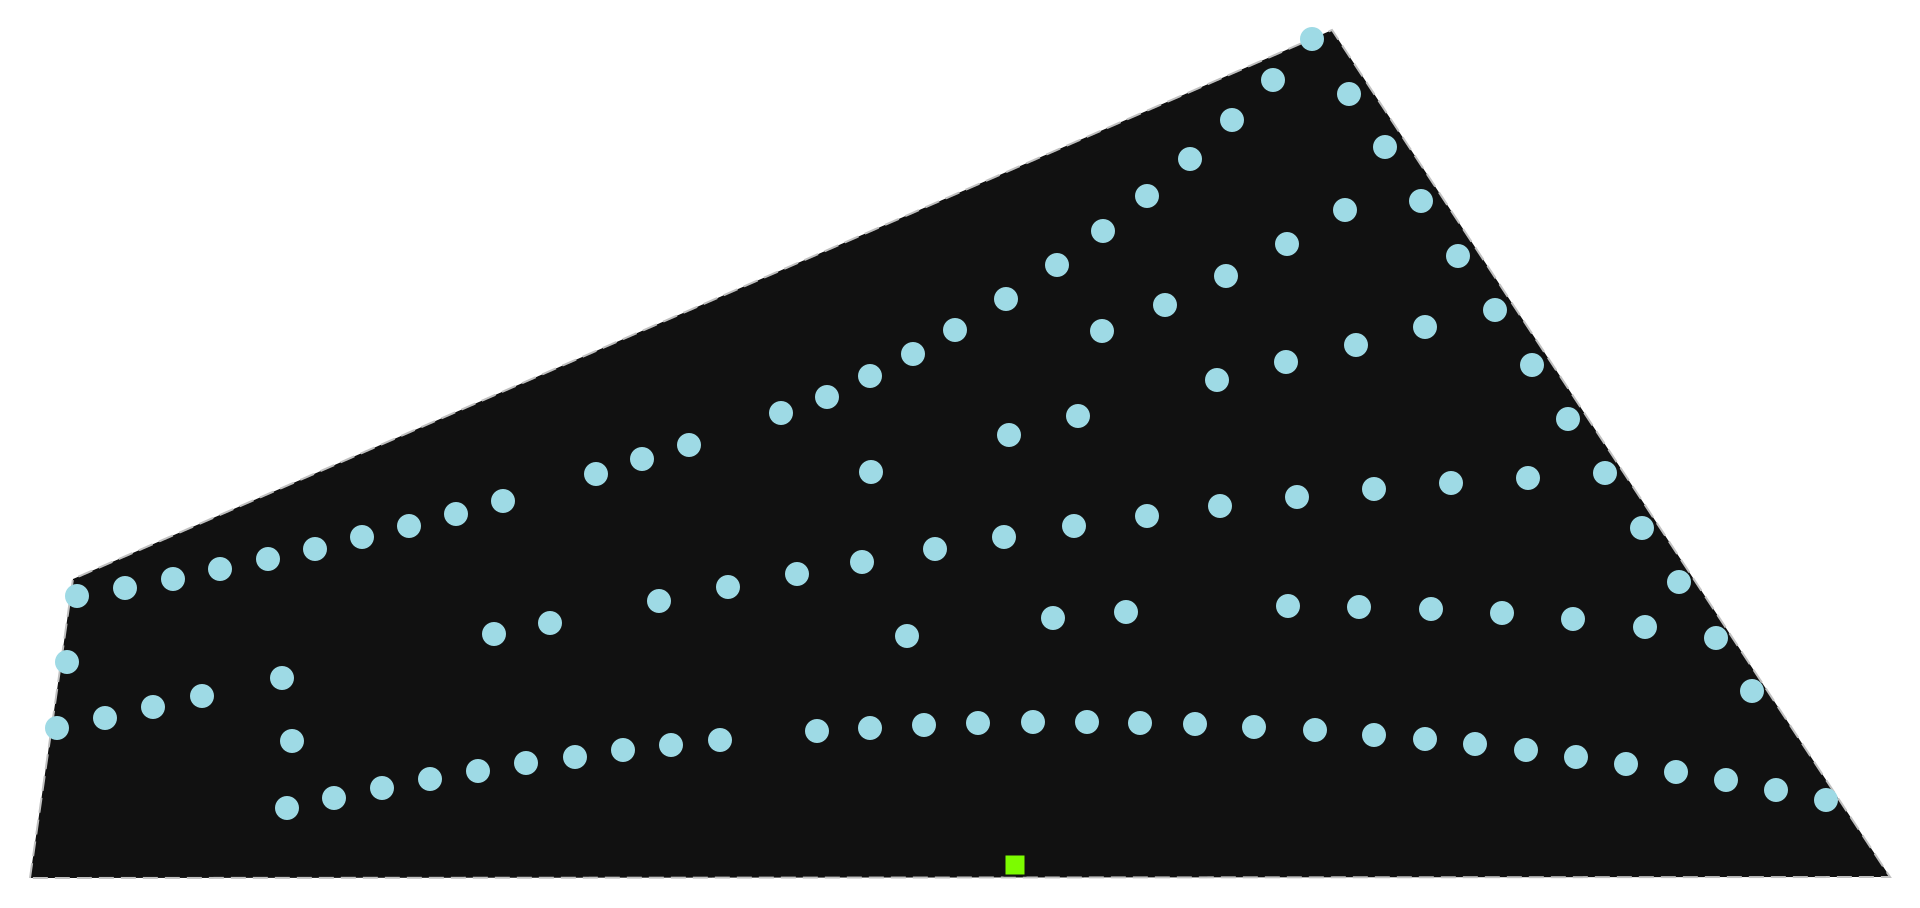

In [5]:
wfn

### Optimize

To plot and visualize the optimized network, an optimization needs to be performed first. Here, the default router (`Heuristics-Esau_Williams`) is used.

In [6]:
res = wfn.optimize()

### Plot the Optimized Network Graph

The optimized network graph (G) represents the optimized network with actual routes.

Accordingly, [wfn.plot()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot) displays the routes for selected links in the **optimized network**. The detoured routes are displayed via dashed lines. Detours are the routes created to resolve crossing feeders.

Turbines that belong to the same subtree are assigned the same color. Each cable type is represented with a distinct line thickness (which gets thicker as the cable capacity increases).

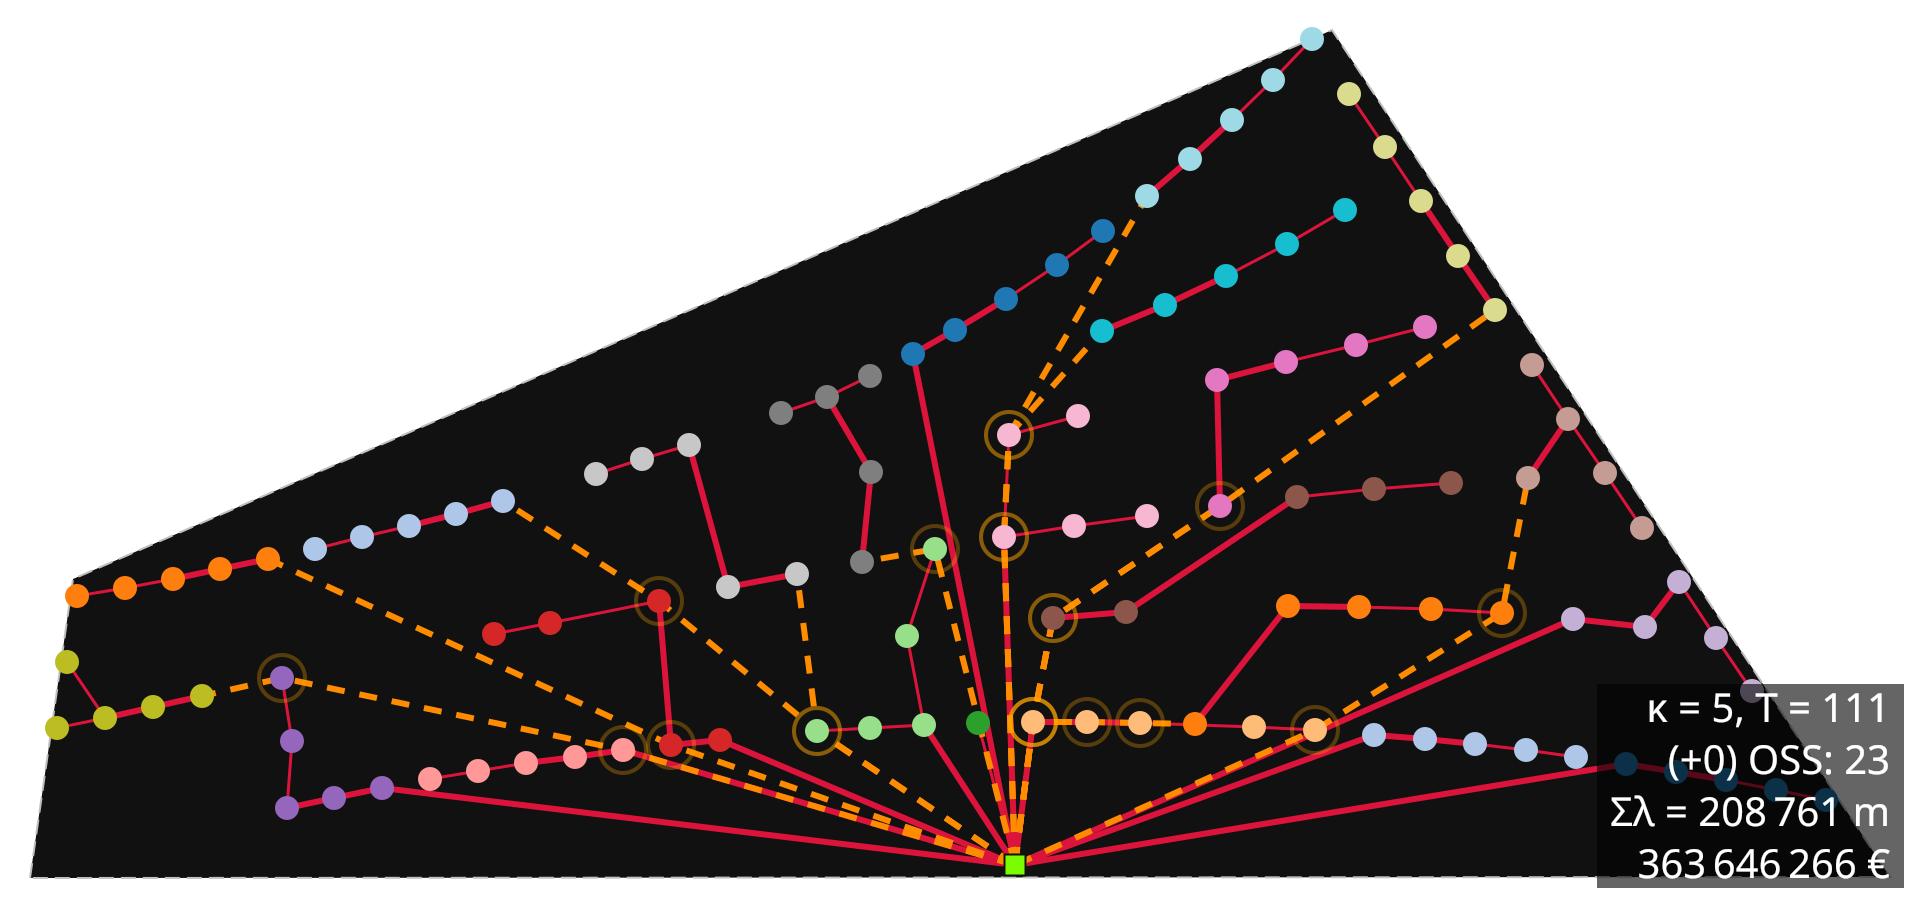

In [7]:
wfn.plot()

> ! Reminder: In a notebook, we can plot the optimized network simply by calling `wfn`:

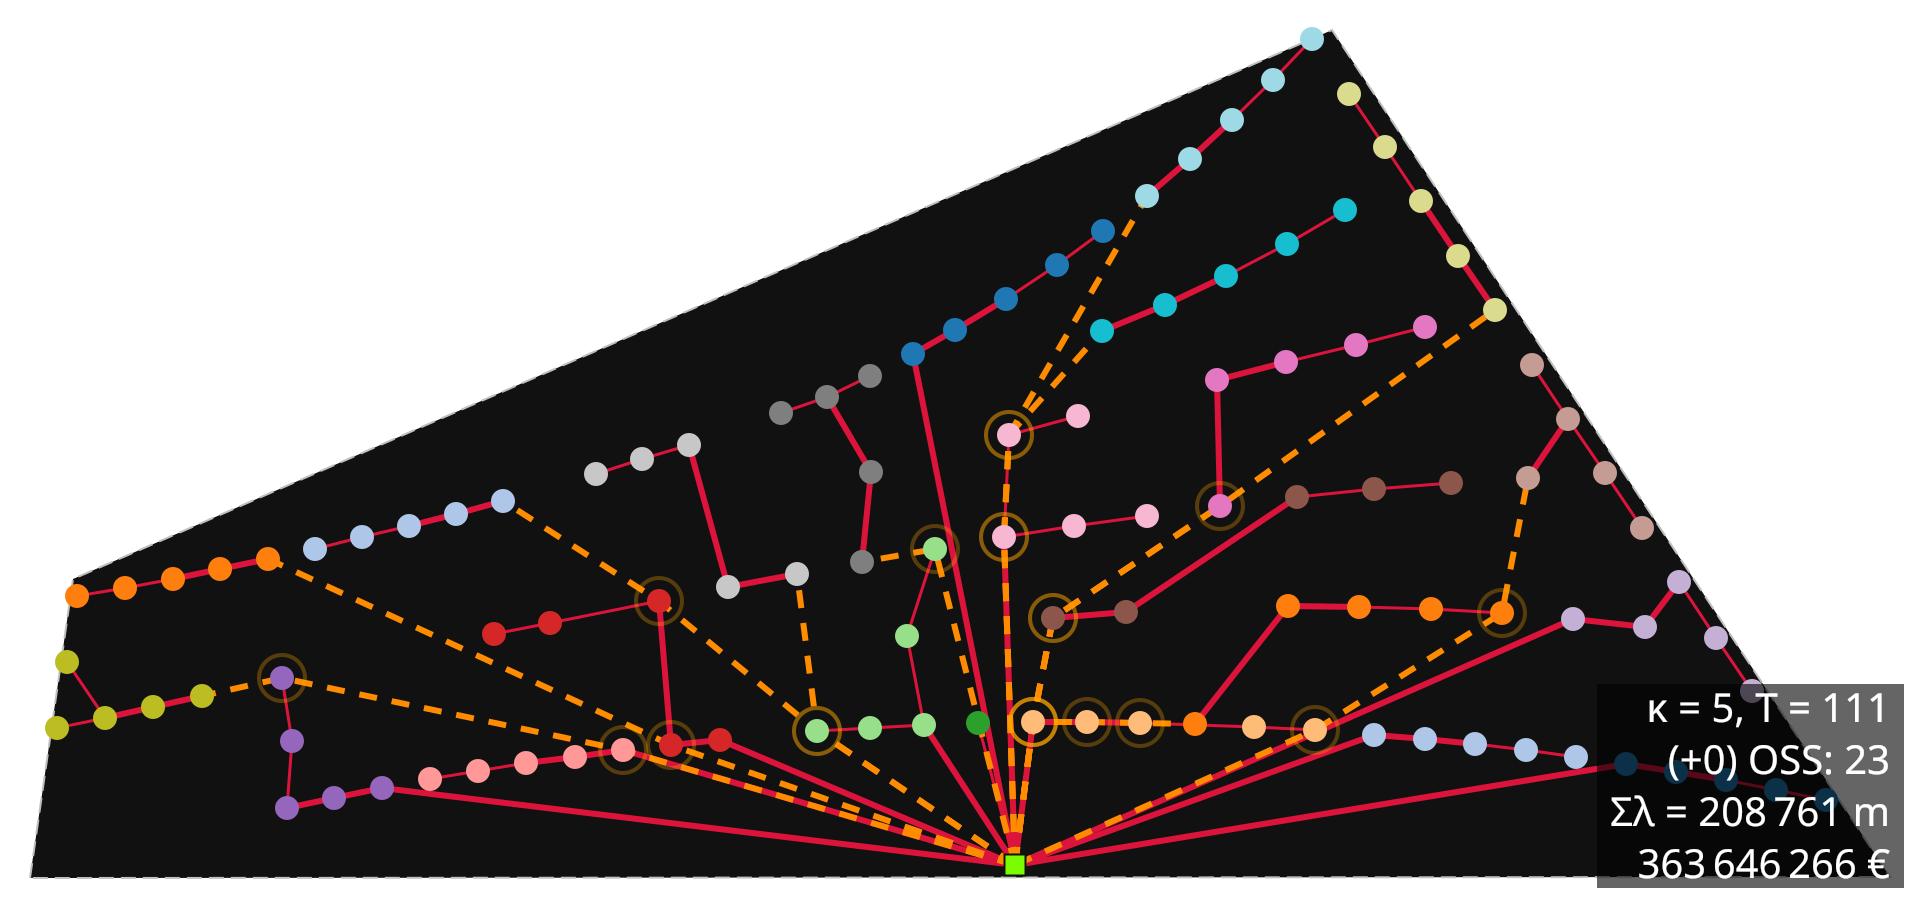

In [8]:
wfn

### Plot in a pre-existing axes

In [9]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

It is also possible to provide a pre-existing `plt.Axes` object within a Matplotlib figure:

> **Tip:**When you pass the `ax` keyword argument to any `wfn` plotting method, it automatically switches under the hood from the native SVG generator to the Matplotlib backend ([gplot](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.gplot)/[pplot](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.pplot)). This allows you to combine and structure multiple plots in standard Matplotlib subplots.

> **Shortcut (No Imports):**If you want to use the Matplotlib backend ([gplot](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.gplot)/[pplot](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.pplot)) but don't want to import Matplotlib/Pyplot in your code, you can simply pass `ax=None` (e.g., `ax = wfn.plot(ax=None)`). The plotting method will detect the `ax` key, switch to the Matplotlib backend, internally import Matplotlib to create a new figure and axes, and return the active `plt.Axes` object.

<Axes: >

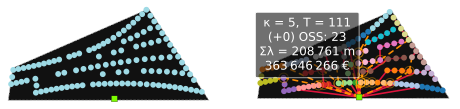

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, facecolor='none', figsize=(8, 4))

wfn.plot_location(ax=ax1)
wfn.plot(ax=ax2, legend=False)

### Optional parameters

#### `node_tag` (text labels)

Node tags make it easier to identify each turbine and substation in the plot. The `node_tag` argument decides what is drawn inside the node symbols:

| Value | Effect |
| --- | --- |
| `True` | The node number — from order of appearance in the data, starting at `0` for terminals and negative for roots. |
| `'label'` | The node's `label` attribute, as defined in the `.yaml` or `.osm.pbf` file, or assigned programmatically. |
| `'load'` | The [load](../reference/glossary.md) exported by the node: for a terminal, the number of terminals upstream including itself; for a root, the total number of terminals connected to it. |
| `'attribute_name'` | The value of any other node attribute. |

Default symbol sizes suit tags of up to three characters; longer tags may not fit.

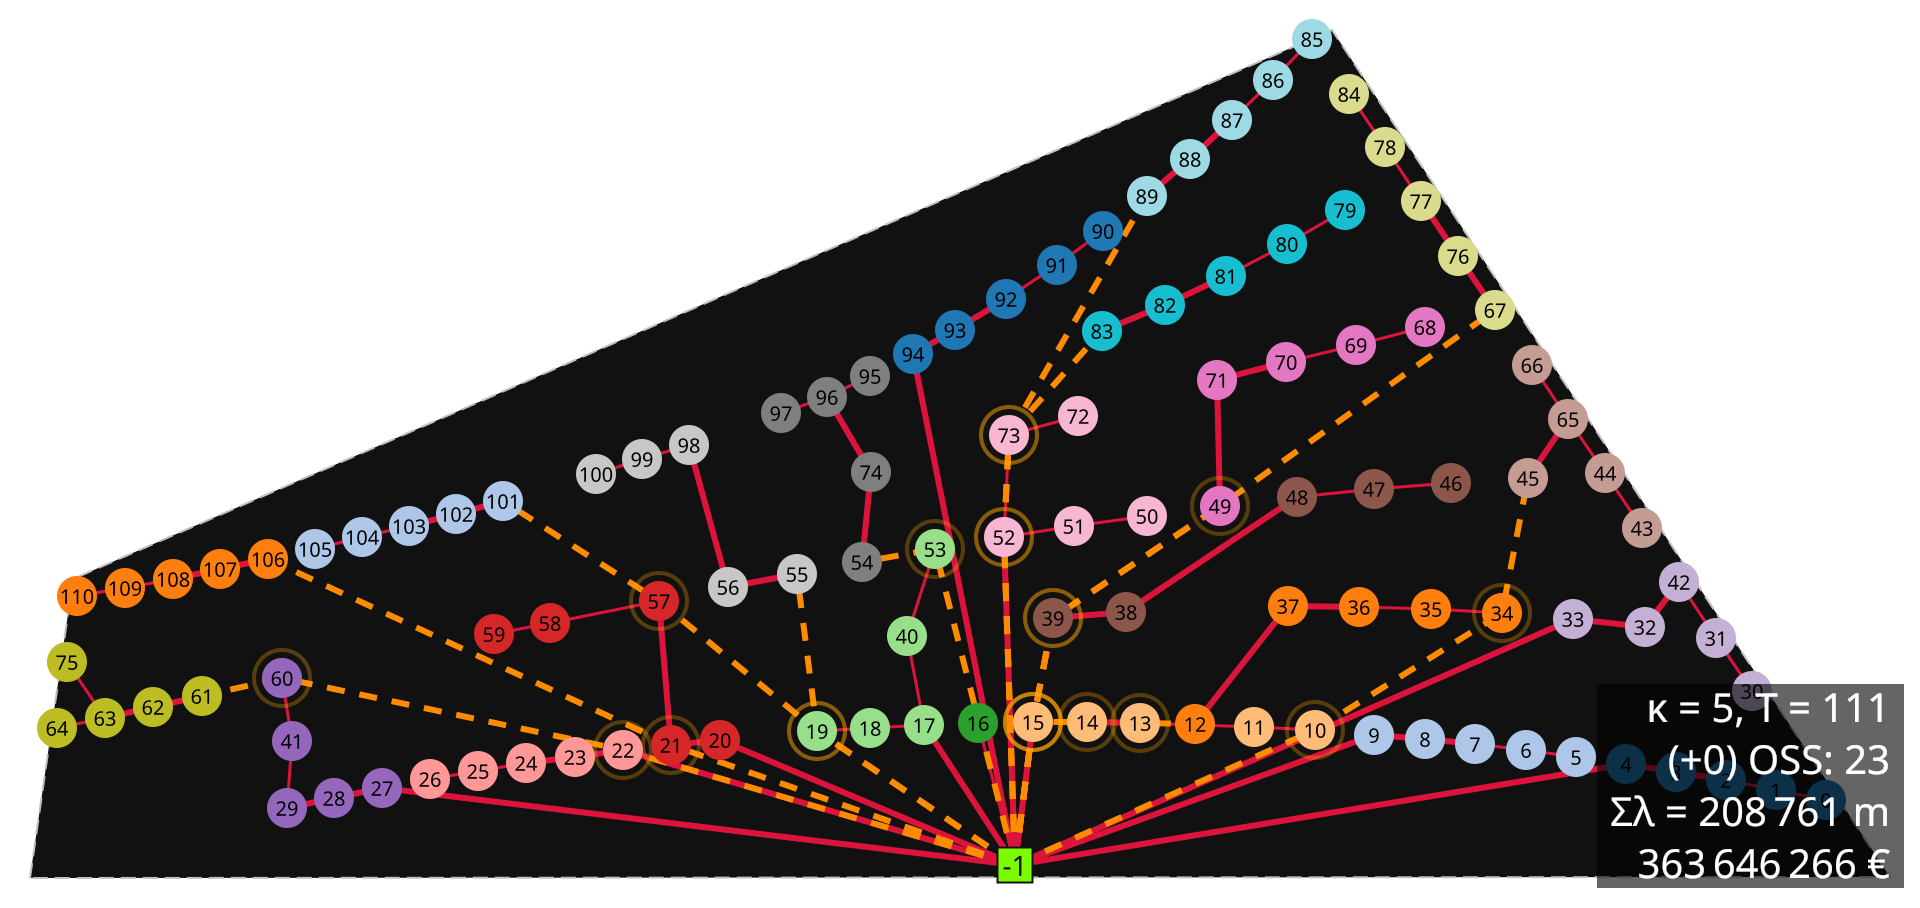

In [11]:
wfn.plot(node_tag=True)

**Labels in location data files**

Labels come from the location data file itself: see [OptiWindNet YAML](../reference/input_formats.md#optiwindnet-yaml) and [OpenStreetMap PBF](../reference/input_formats.md#openstreetmap-pbf) for how they are declared in each format. They can also be assigned programmatically, as below.

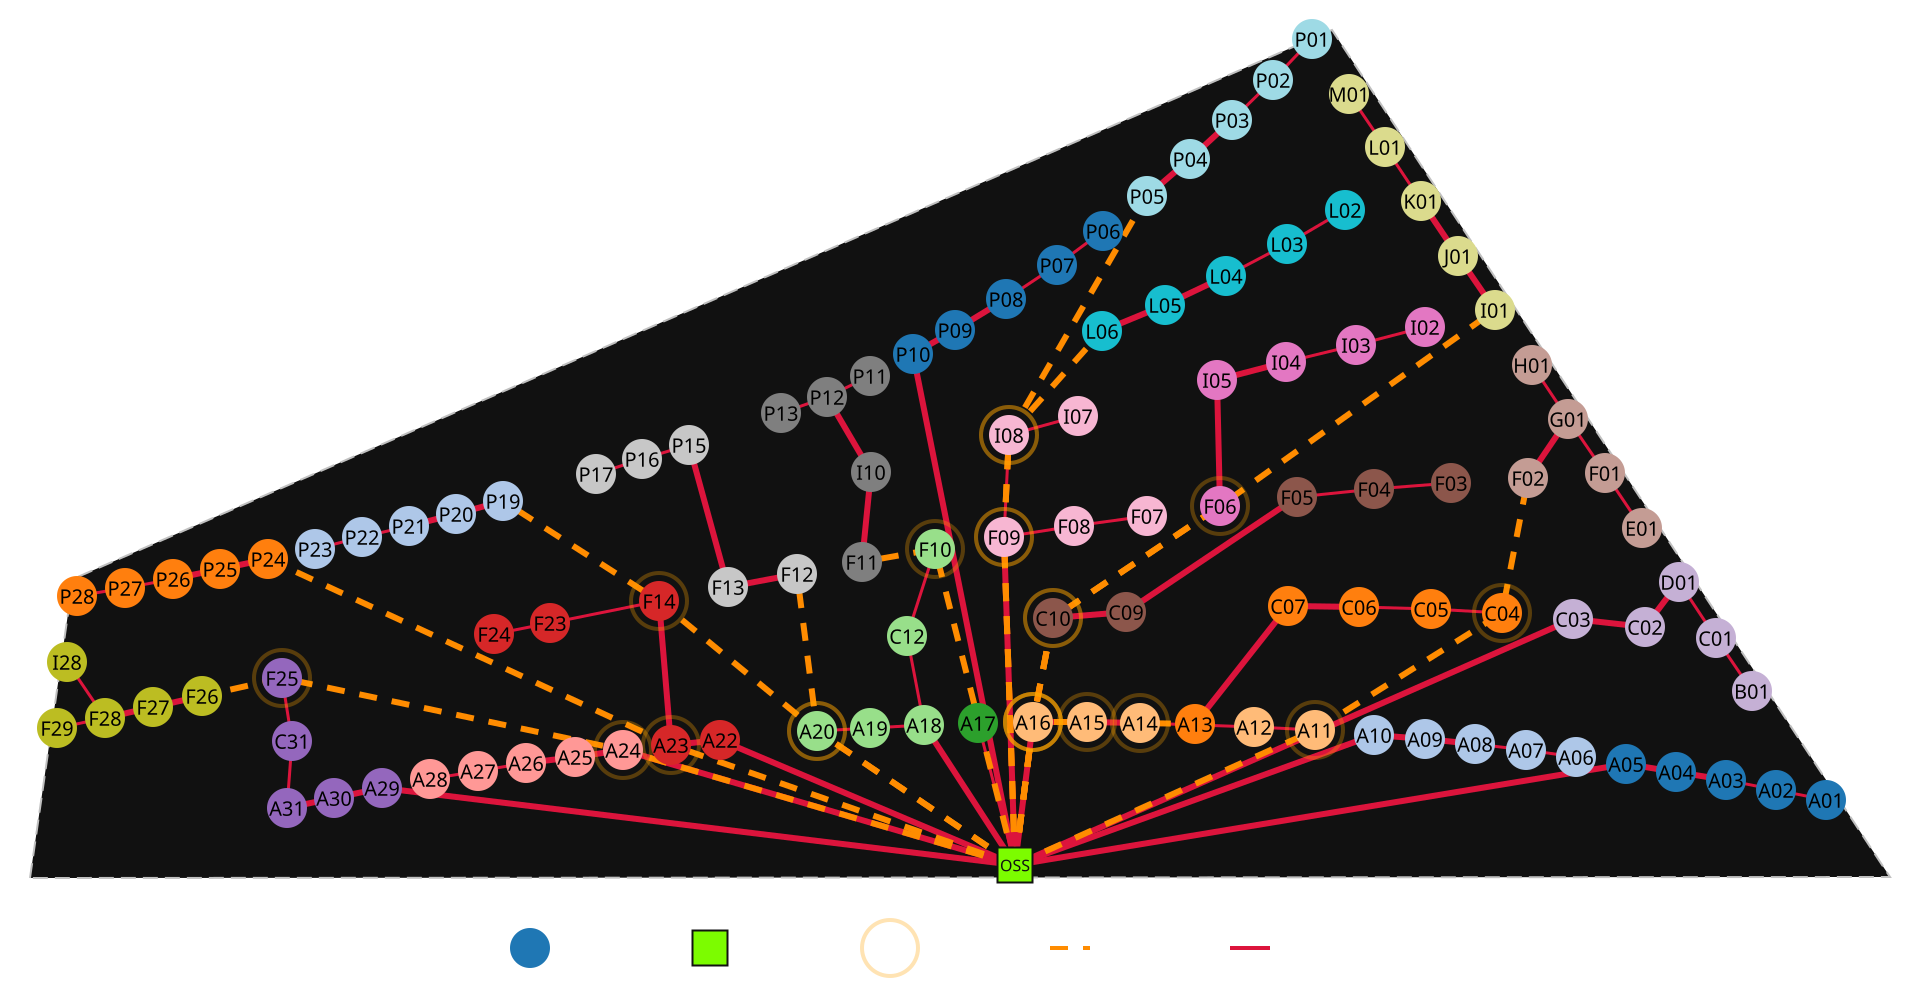

In [12]:
wfn.plot(node_tag='label', infobox=False, legend=True)

In [13]:
wfn.L.nodes[0]['example_label']='T0'

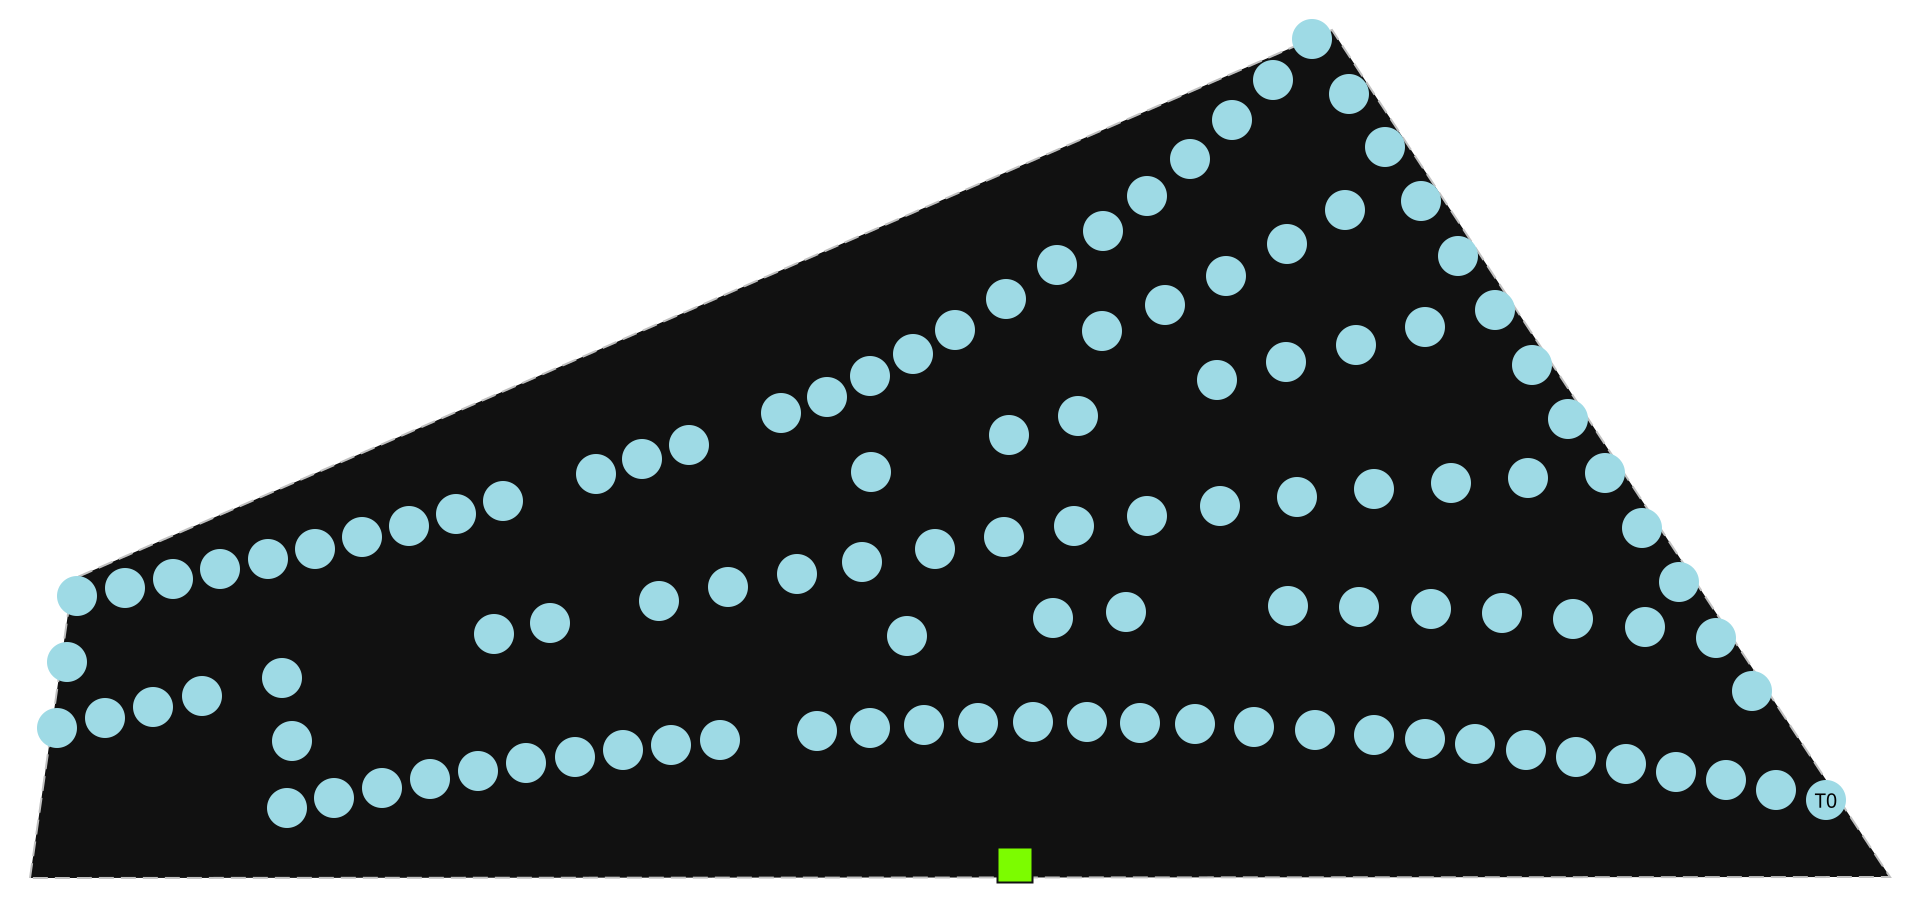

In [14]:
wfn.plot_location(node_tag='example_label')

The nodes can also be tagged with the [load](../reference/glossary.md) they export towards the substation:

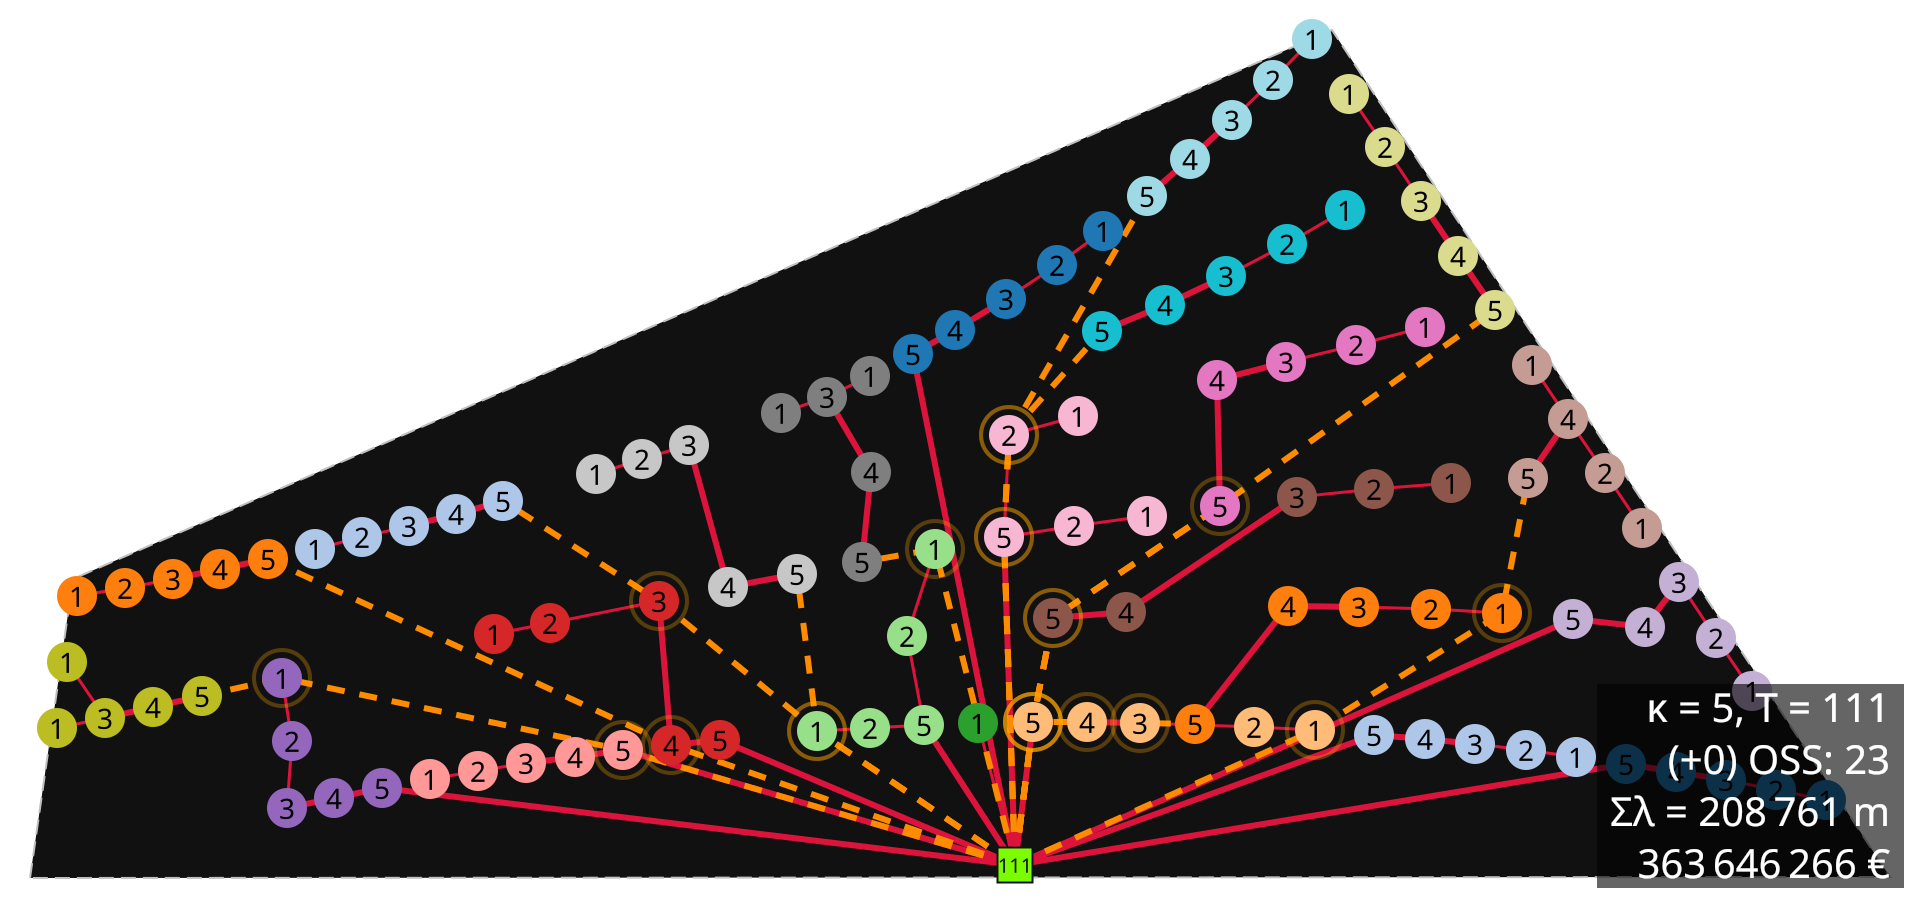

In [15]:
wfn.plot(node_tag='load')

#### `dark` (color theme)

The theme is matched to the operating system's by default, through the `darkdetect` package — note that this detects the _system_ theme, not JupyterLab's, so the two can disagree. Set `dark=True` or `dark=False` to decide explicitly.

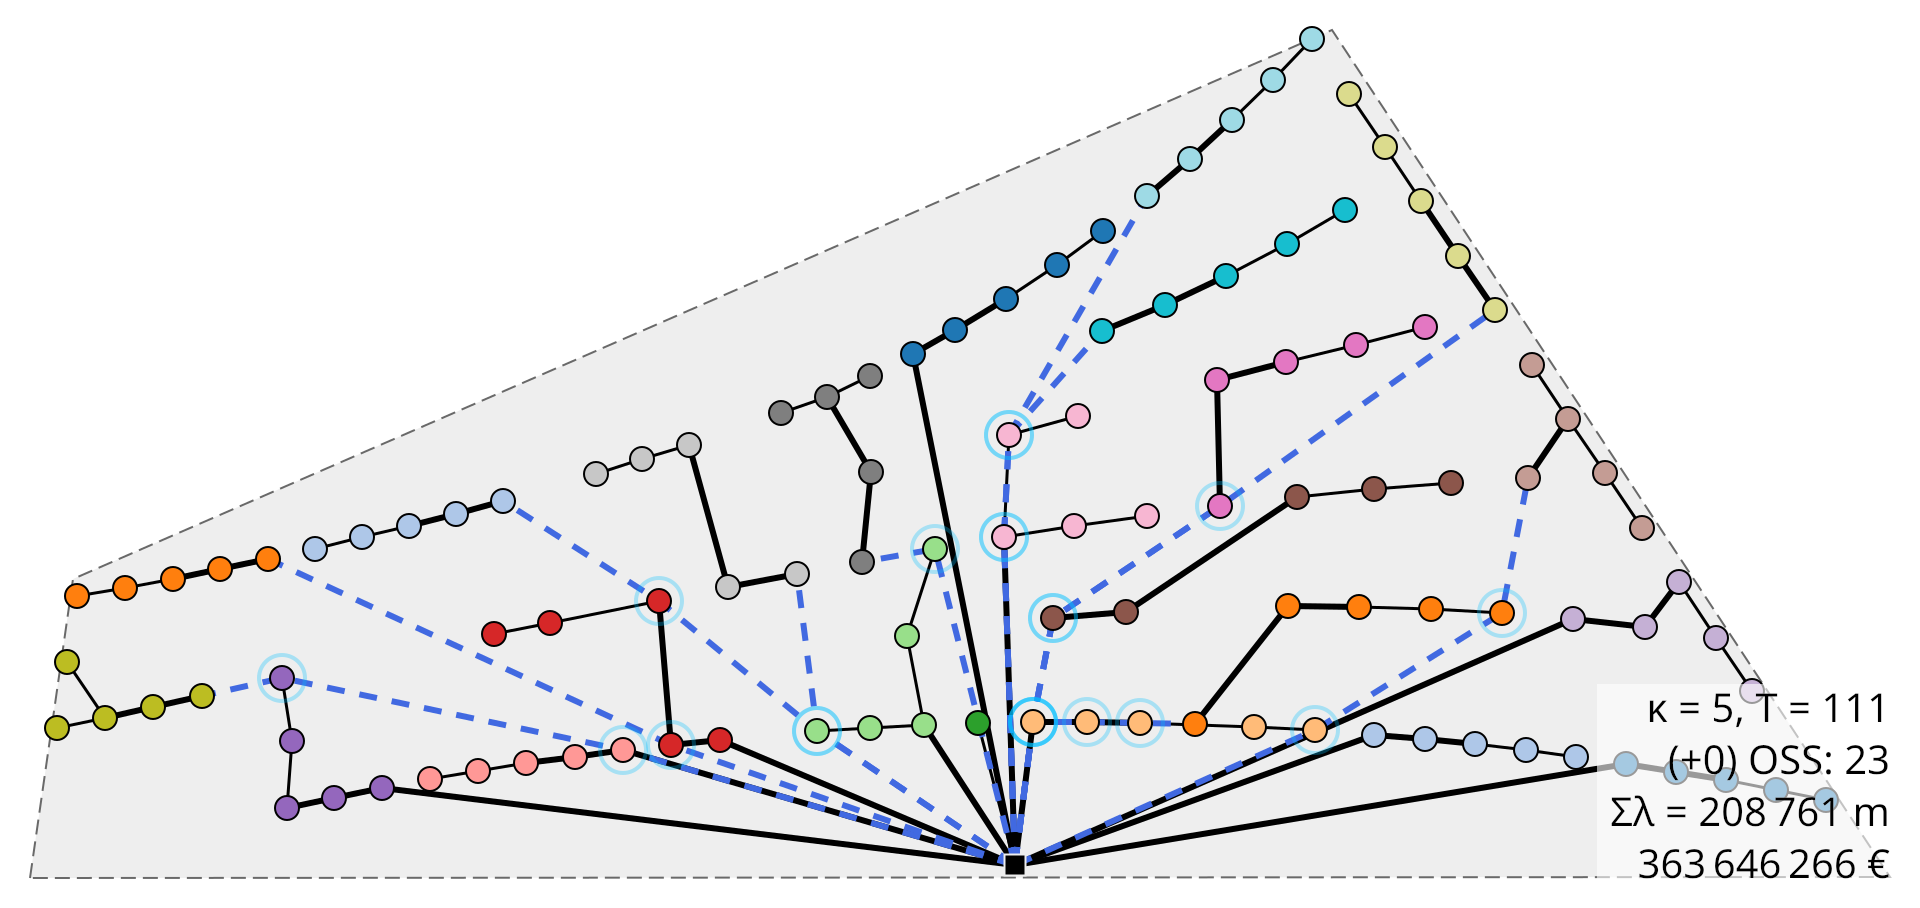

In [16]:
wfn.plot(dark=False)

#### `landscape_angle` (rotation)

Each location included in `OptiWindNet` has a graph attribute called `landscape_angle`.

In [17]:
wfn.L.graph['landscape_angle']

81.8

This is the angle by which to rotate the site so as to orient the widest dimension horizontally. Pass `landscape=False` to orient the location with north up instead.

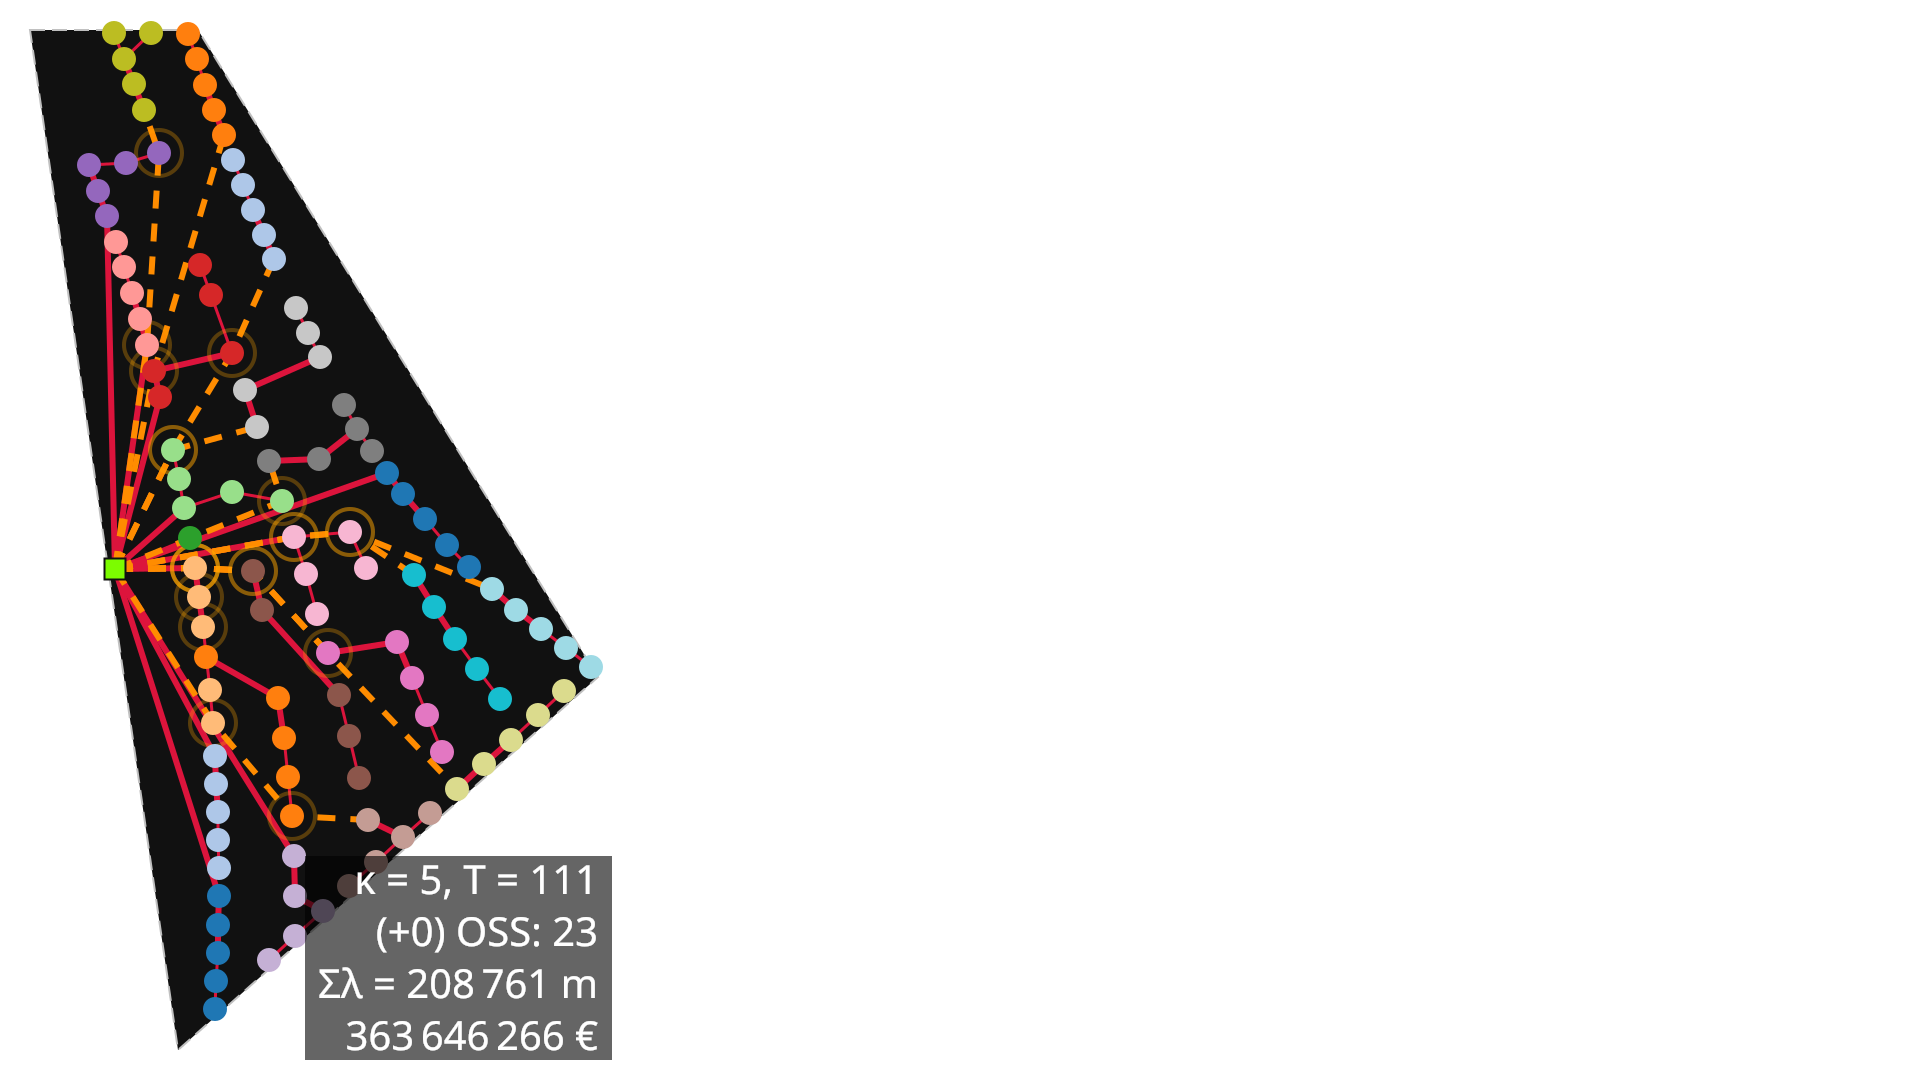

In [18]:
wfn.plot(landscape=False)

### Plotting Auxiliary Graphs

Of the **five plot methods**, [wfn.plot_location()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_location) and [wfn.plot()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot) have been presented above.

The remaining three show the auxiliary graphs `navigation_mesh`, `available_links` and `selected_links`, which are relevant mainly for **debugging** and **development**. The [graph model and plot views](../problem.md#the-graph-model) describe what each view means and the graph underlying it.

#### Navigation mesh

The _navigation mesh_ is the constrained Delaunay triangulation stored in [wfn.P](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.P).

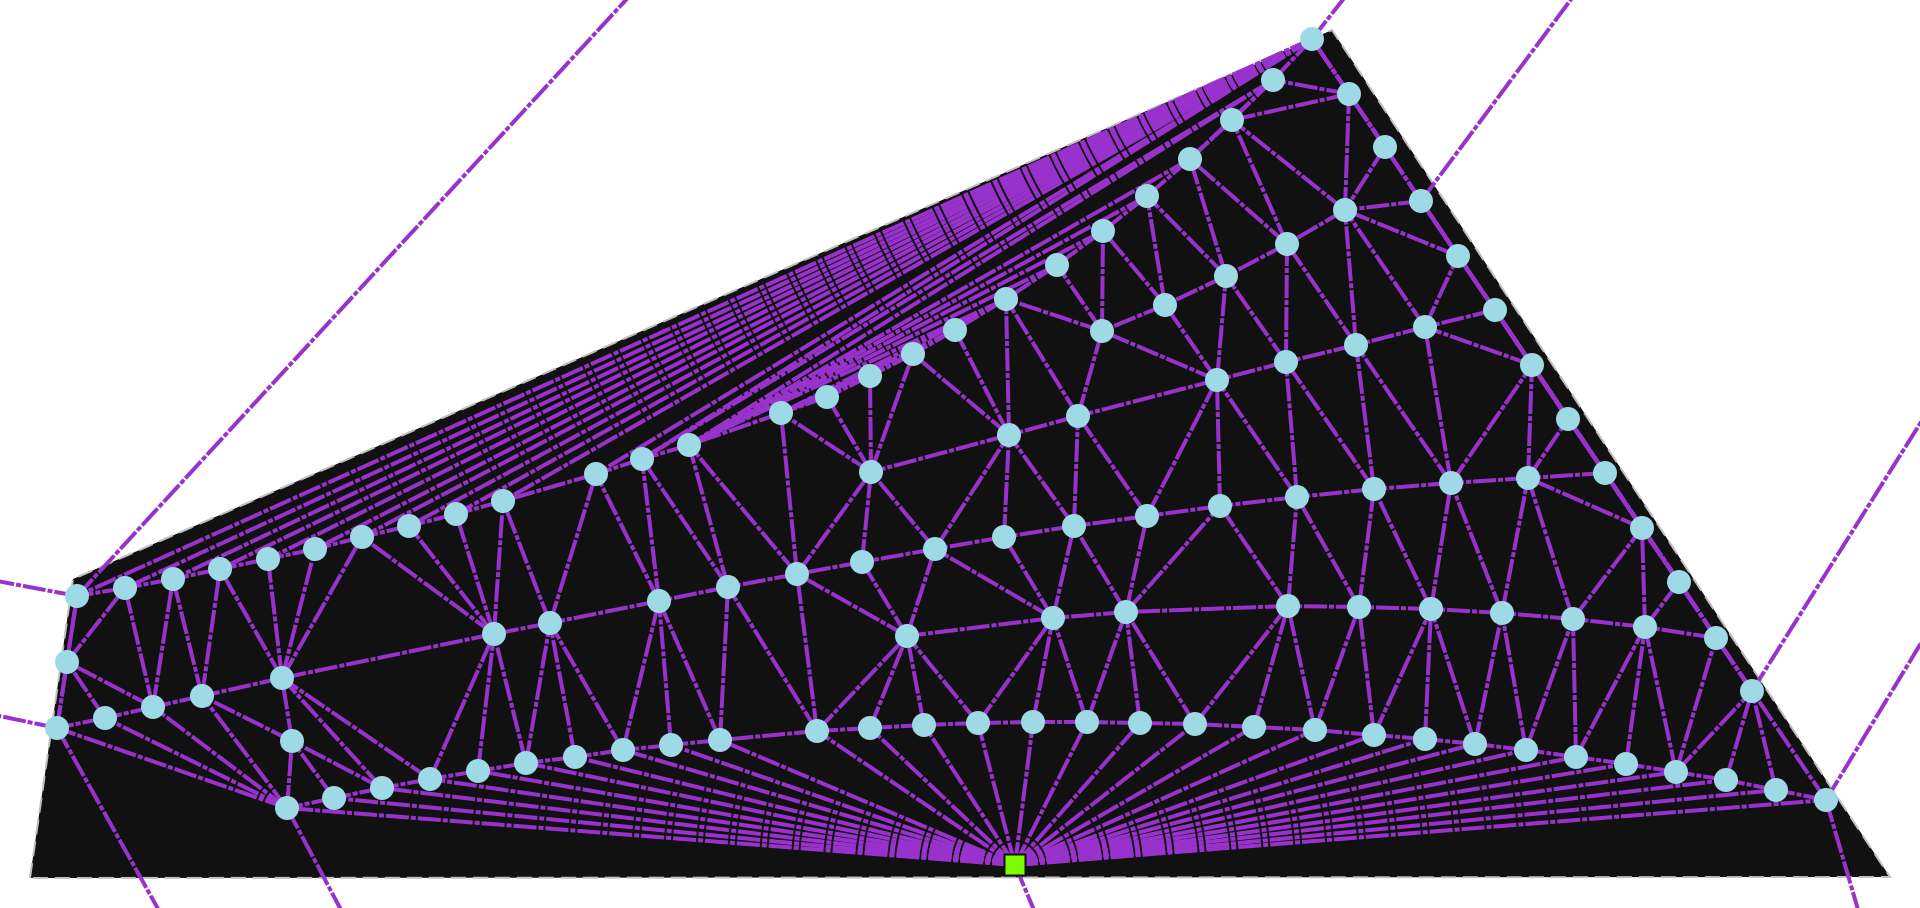

In [19]:
wfn.plot_navigation_mesh()

#### Available Links

The _available links_ graph is the search space [wfn.A](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.A), from which the router selects a subset.

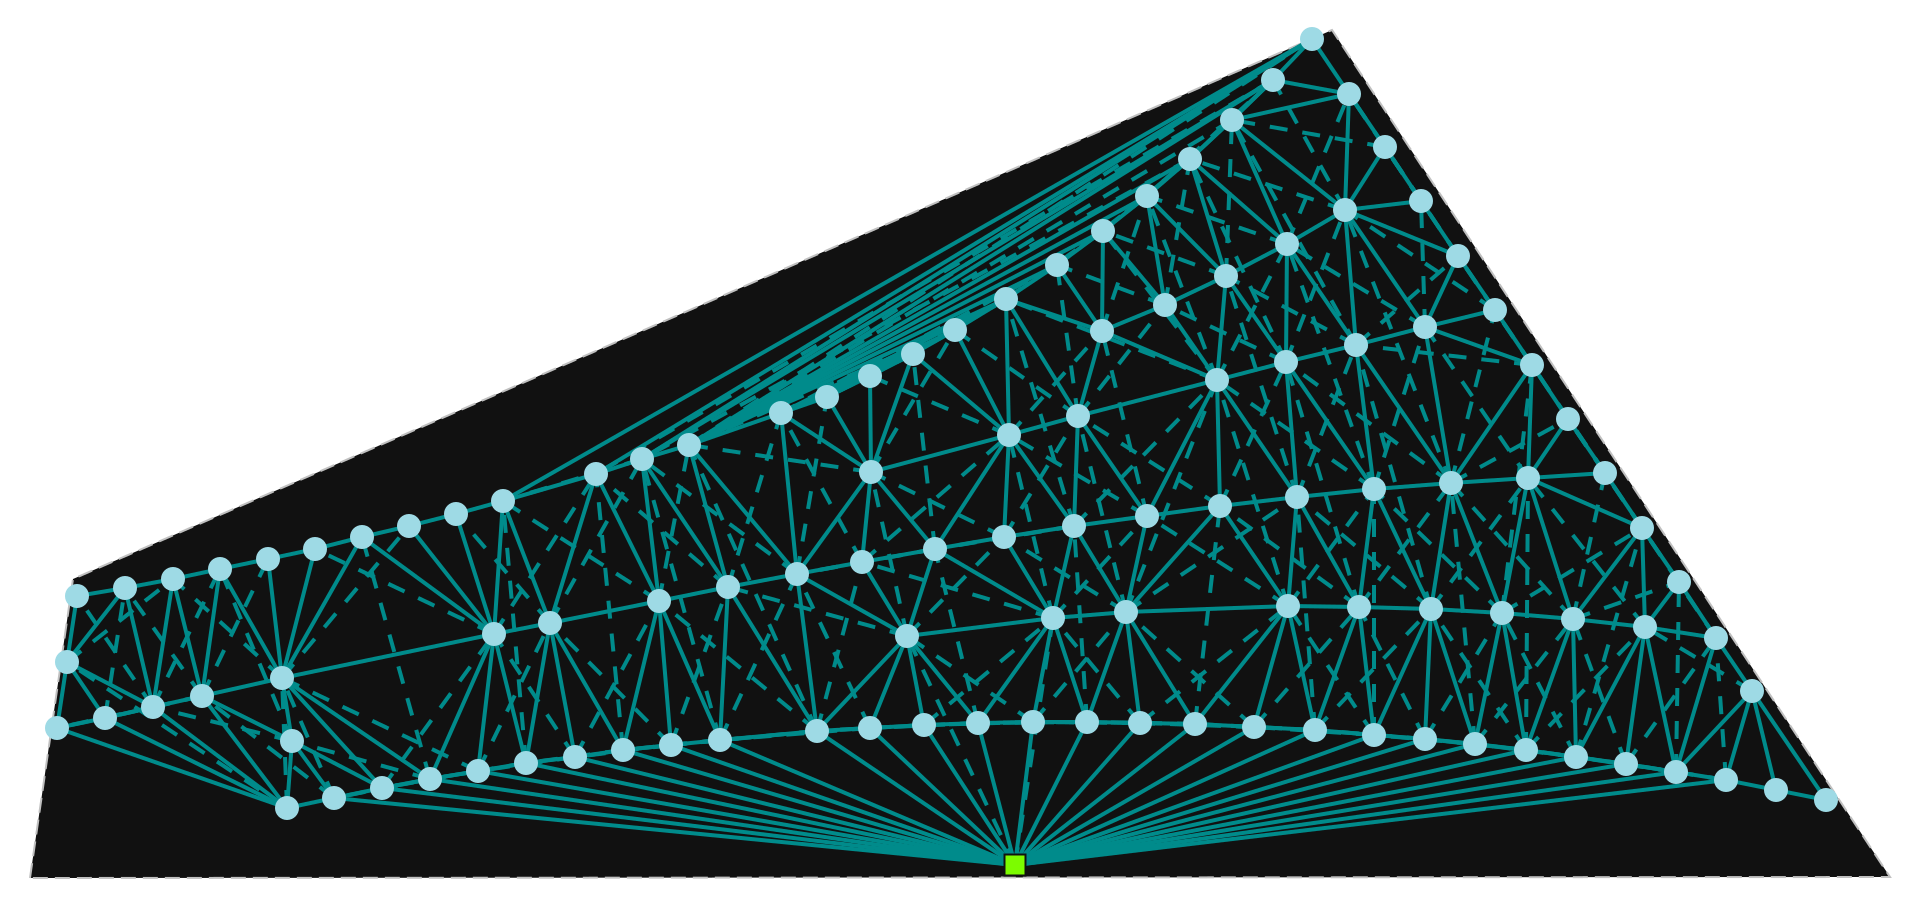

In [20]:
wfn.plot_available_links()

#### Selected Links

[wfn.plot_selected_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_selected_links) displays the **links selected** from the available links by the router algorithm.

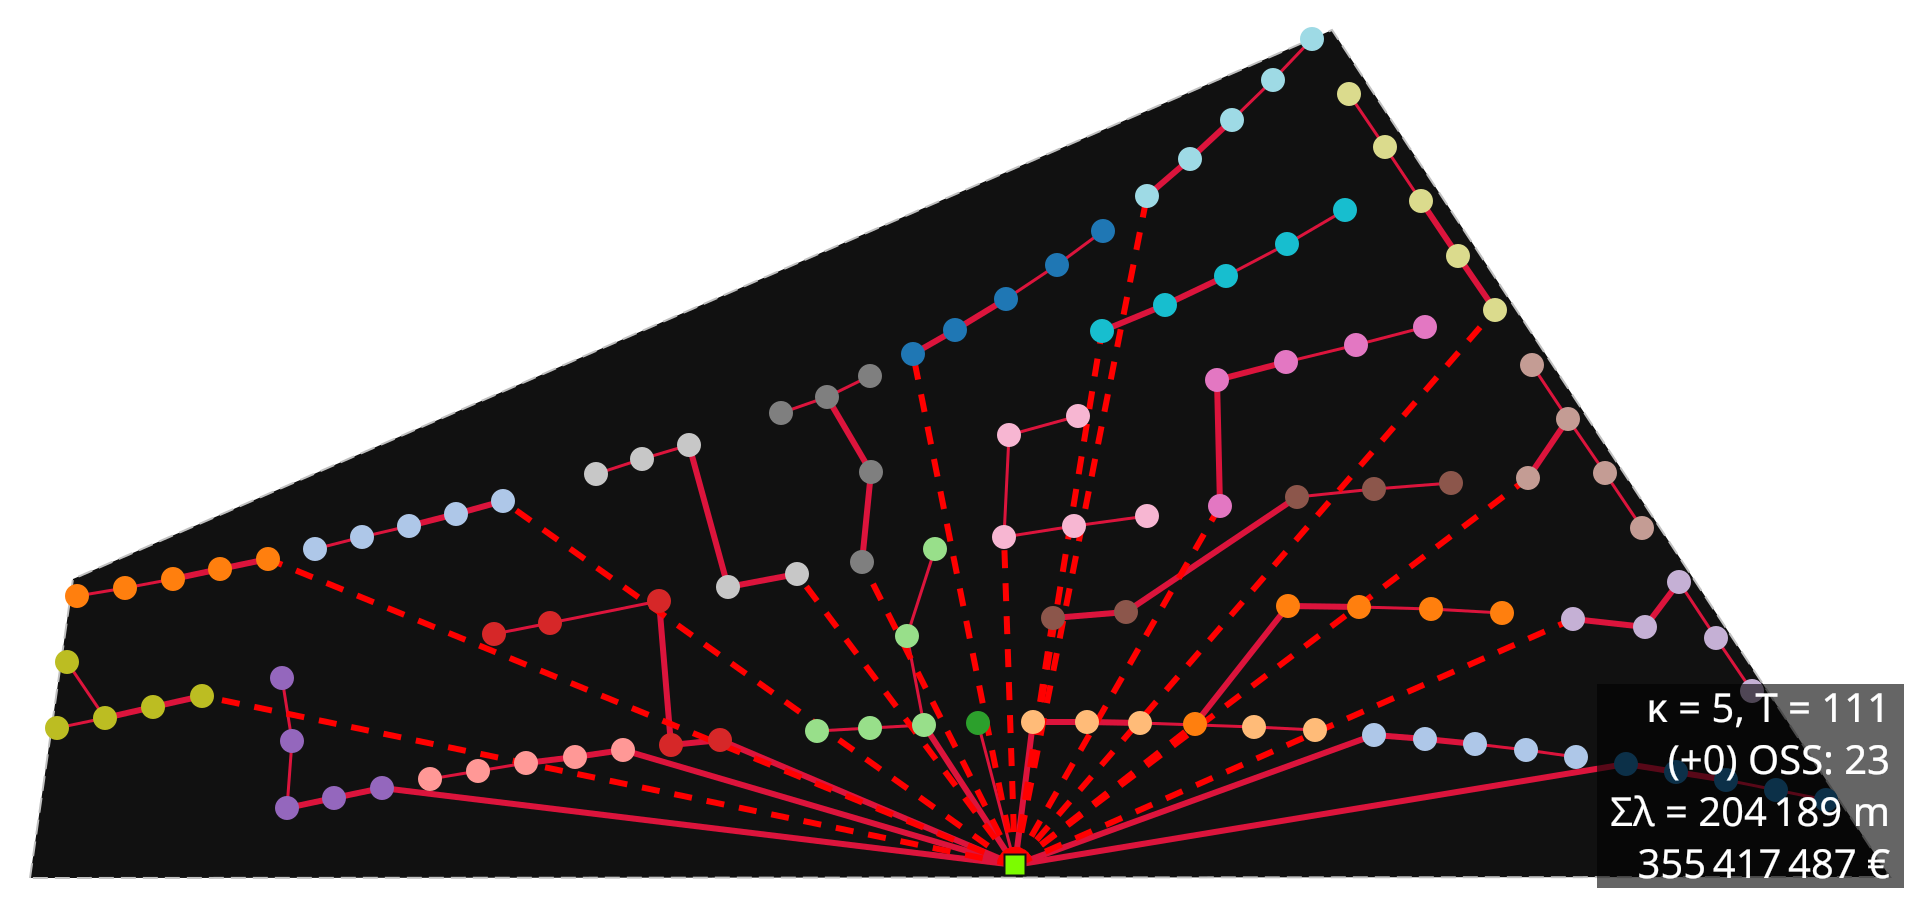

In [21]:
wfn.plot_selected_links()

To clarify the difference between [wfn.plot_selected_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_selected_links) and [wfn.plot()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot), compare the definitions of [link and route](../reference/glossary.md): the former draws the electrical connections, the latter the paths the cables actually take.